In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data="/content/Exam_Score_Prediction.csv"

In [ ]:
df=pd.read_csv(data)
df

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19997,18,other,bba,6.50,71.3,yes,5.0,good,self-study,low,easy,86.5
19996,19998,18,male,b.com,3.71,41.6,no,5.9,average,coaching,medium,moderate,60.9
19997,19999,19,other,diploma,7.88,68.2,yes,4.6,poor,group study,low,easy,64.5
19998,20000,19,male,bba,4.60,76.3,no,6.1,good,self-study,medium,moderate,79.0


# **first five rows**

In [ ]:
df.head()

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


# last five rows

In [ ]:
df.tail()

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
19995,19997,18,other,bba,6.50,71.3,yes,5.0,good,self-study,low,easy,86.5
19996,19998,18,male,b.com,3.71,41.6,no,5.9,average,coaching,medium,moderate,60.9
19997,19999,19,other,diploma,7.88,68.2,yes,4.6,poor,group study,low,easy,64.5
19998,20000,19,male,bba,4.60,76.3,no,6.1,good,self-study,medium,moderate,79.0
19999,20001,20,male,b.sc,7.50,47.9,yes,7.5,poor,coaching,medium,moderate,71.0


# total row and columns



In [ ]:
df.shape

(20000, 13)

# display column names

In [ ]:
df.columns

Index(['student_id', 'age', 'gender', 'course', 'study_hours',
       'class_attendance', 'internet_access', 'sleep_hours', 'sleep_quality',
       'study_method', 'facility_rating', 'exam_difficulty', 'exam_score'],
      dtype='object')

# dataset information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        20000 non-null  int64  
 1   age               20000 non-null  int64  
 2   gender            20000 non-null  object 
 3   course            20000 non-null  object 
 4   study_hours       20000 non-null  float64
 5   class_attendance  20000 non-null  float64
 6   internet_access   20000 non-null  object 
 7   sleep_hours       20000 non-null  float64
 8   sleep_quality     20000 non-null  object 
 9   study_method      20000 non-null  object 
 10  facility_rating   20000 non-null  object 
 11  exam_difficulty   20000 non-null  object 
 12  exam_score        20000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 2.0+ MB


# Statistical Summary

In [ ]:
df.describe()

,student_id,age,study_hours,class_attendance,sleep_hours,exam_score
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000
mean,10000.504600,20.473300,4.007604,70.017365,7.00856,62.513225
std,5773.654959,2.284458,2.308313,17.282262,1.73209,18.908491
min,1.000000,17.000000,0.080000,40.600000,4.10000,19.599000
25%,5000.750000,18.000000,2.000000,55.100000,5.50000,48.800000
50%,10000.500000,20.000000,4.040000,69.900000,7.00000,62.600000
75%,15000.250000,22.000000,6.000000,85.000000,8.50000,76.300000
max,20001.000000,24.000000,7.910000,99.400000,9.90000,100.000000


# Check Missing Values

In [ ]:
df.isnull().sum()

,0
student_id,0
age,0
gender,0
course,0
study_hours,0
class_attendance,0
internet_access,0
sleep_hours,0
sleep_quality,0
study_method,0


# Check duplicate rows

In [ ]:
df.duplicated().sum()

np.int64(0)

# check datatypes

In [ ]:
df.dtypes

,0
student_id,int64
age,int64
gender,object
course,object
study_hours,float64
class_attendance,float64
internet_access,object
sleep_hours,float64
sleep_quality,object
study_method,object


# Find Categorical Columns

In [ ]:
df.select_dtypes(include='object').columns

Index(['gender', 'course', 'internet_access', 'sleep_quality', 'study_method',
       'facility_rating', 'exam_difficulty'],
      dtype='object')

# Convert Categorical Data into Numerical Data

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for column in df.select_dtypes(include='object').columns:
    df[column] = le.fit_transform(df[column])

print("Categorical columns converted successfully.")

Categorical columns converted successfully.


# Check Dataset After Encoding

In [ ]:
df.head()

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,1,6,2.78,92.9,1,7.4,2,0,1,1,58.9
1,2,23,2,5,3.37,64.8,1,4.6,0,3,2,2,54.8
2,3,22,1,1,7.88,76.8,1,8.5,2,0,0,2,90.3
3,4,20,2,6,0.67,48.4,1,5.8,0,3,1,2,29.7
4,5,20,0,6,0.89,71.6,1,9.8,2,0,1,2,43.7


# Check Null Values Again

In [ ]:
df.isnull().sum()

,0
student_id,0
age,0
gender,0
course,0
study_hours,0
class_attendance,0
internet_access,0
sleep_hours,0
sleep_quality,0
study_method,0


# Check Final Dataset Information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        20000 non-null  int64  
 1   age               20000 non-null  int64  
 2   gender            20000 non-null  int64  
 3   course            20000 non-null  int64  
 4   study_hours       20000 non-null  float64
 5   class_attendance  20000 non-null  float64
 6   internet_access   20000 non-null  int64  
 7   sleep_hours       20000 non-null  float64
 8   sleep_quality     20000 non-null  int64  
 9   study_method      20000 non-null  int64  
 10  facility_rating   20000 non-null  int64  
 11  exam_difficulty   20000 non-null  int64  
 12  exam_score        20000 non-null  float64
dtypes: float64(4), int64(9)
memory usage: 2.0 MB


# Import Models

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

# Create Result Column

In [ ]:
df["Result"] = df["exam_score"].apply(lambda x: 1 if x >= 40 else 0)
df

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score,Result
0,1,17,1,6,2.78,92.9,1,7.4,2,0,1,1,58.9,1
1,2,23,2,5,3.37,64.8,1,4.6,0,3,2,2,54.8,1
2,3,22,1,1,7.88,76.8,1,8.5,2,0,0,2,90.3,1
3,4,20,2,6,0.67,48.4,1,5.8,0,3,1,2,29.7,0
4,5,20,0,6,0.89,71.6,1,9.8,2,0,1,2,43.7,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19997,18,2,4,6.50,71.3,1,5.0,1,4,1,0,86.5,1
19996,19998,18,1,0,3.71,41.6,0,5.9,0,0,2,2,60.9,1
19997,19999,19,2,6,7.88,68.2,1,4.6,2,1,1,0,64.5,1
19998,20000,19,1,4,4.60,76.3,0,6.1,1,4,2,2,79.0,1


# Define Features (X) and Target (y)

In [ ]:
X = df.drop(["exam_score", "Result"], axis=1)
y = df["Result"]

# split dataset into train test split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# check rows and columns

In [ ]:
print("X_train :", X_train.shape)

print("X_test :", X_test.shape)

print("y_train :", y_train.shape)

print("y_test :", y_test.shape)

X_train : (16000, 12)
X_test : (4000, 12)
y_train : (16000,)
y_test : (4000,)


# Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# Train Decision Tree

In [ ]:
dt_model = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

# Decision Tree Prediction

In [ ]:
dt_prediction = dt_model.predict(X_test)

print(dt_prediction)

[0 1 1 ... 1 1 1]


# Train SVM

In [ ]:
svm_model = SVC(
    kernel="rbf",
    random_state=42
)

svm_model.fit(X_train, y_train)

SVC(random_state=42)

# SVM Prediction

In [ ]:
svm_prediction = svm_model.predict(X_test)

print(svm_prediction)

[0 1 1 ... 1 1 1]


# decision tree accuracy

In [ ]:
from sklearn.metrics import accuracy_score

dt_accuracy = accuracy_score(y_test, dt_prediction)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.85525


# SVM accuracy

In [ ]:
svm_accuracy = accuracy_score(y_test, svm_prediction)

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.906


# confusion matrix for decision tree

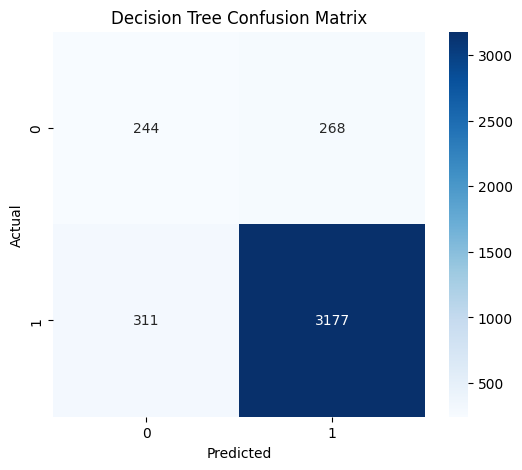

In [ ]:
from sklearn.metrics import confusion_matrix
dt_cm = confusion_matrix(y_test, dt_prediction)

plt.figure(figsize=(6,5))

sns.heatmap(dt_cm,
            annot=True,
            cmap="Blues",
            fmt="d")

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# confusion matrix for SVM

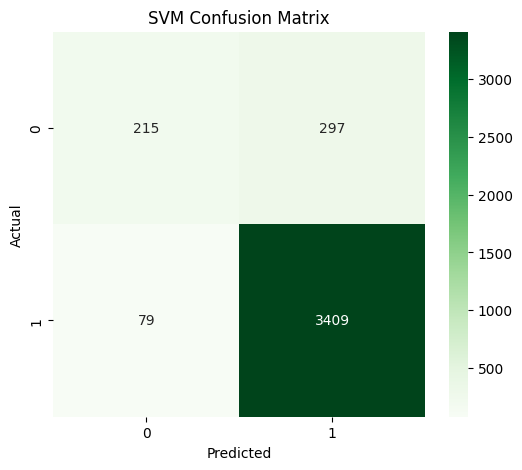

In [ ]:
svm_cm = confusion_matrix(y_test, svm_prediction)

plt.figure(figsize=(6,5))

sns.heatmap(svm_cm,
            annot=True,
            cmap="Greens",
            fmt="d")

plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# classification of both

In [ ]:
from sklearn.metrics import classification_report

print("Decision Tree Report")
print(classification_report(y_test, dt_prediction))

print("--------------------------------")

print("SVM Report")
print(classification_report(y_test, svm_prediction))

Decision Tree Report
              precision    recall  f1-score   support

           0       0.44      0.48      0.46       512
           1       0.92      0.91      0.92      3488

    accuracy                           0.86      4000
   macro avg       0.68      0.69      0.69      4000
weighted avg       0.86      0.86      0.86      4000

--------------------------------
SVM Report
              precision    recall  f1-score   support

           0       0.73      0.42      0.53       512
           1       0.92      0.98      0.95      3488

    accuracy                           0.91      4000
   macro avg       0.83      0.70      0.74      4000
weighted avg       0.90      0.91      0.89      4000



# accuracy comparison graph

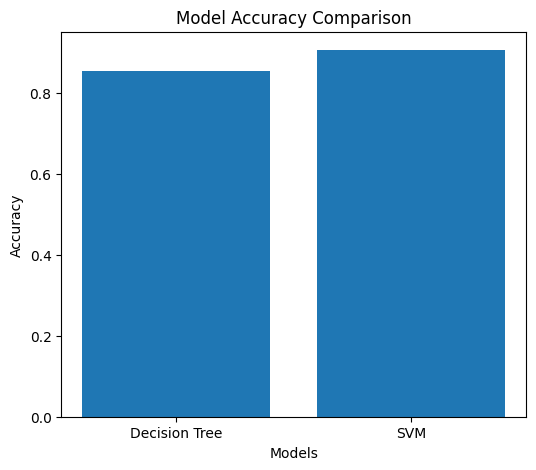

In [ ]:
models = ["Decision Tree","SVM"]

accuracy = [dt_accuracy, svm_accuracy]

plt.figure(figsize=(6,5))

plt.bar(models, accuracy)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.show()

# Decision Tree Visualization

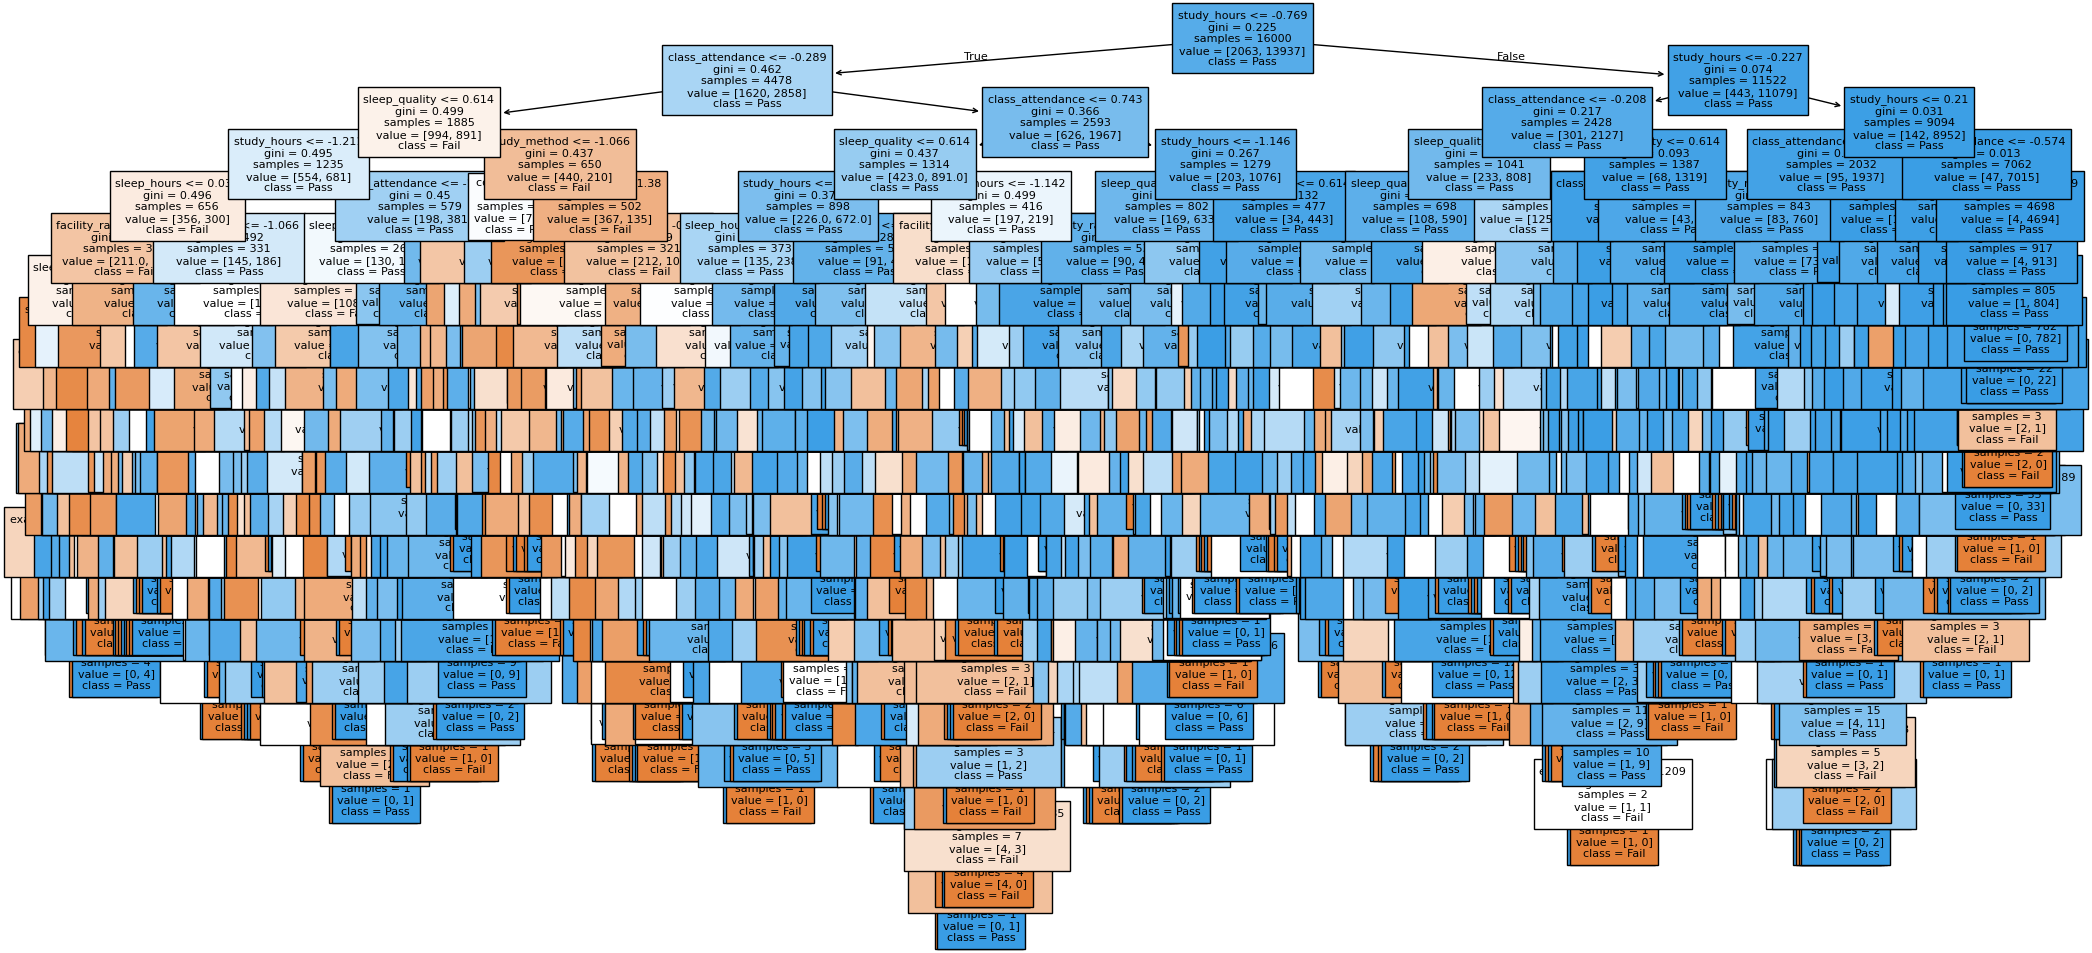

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(25,12))

plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=["Fail","Pass"],
    filled=True,
    fontsize=8
)

plt.show()

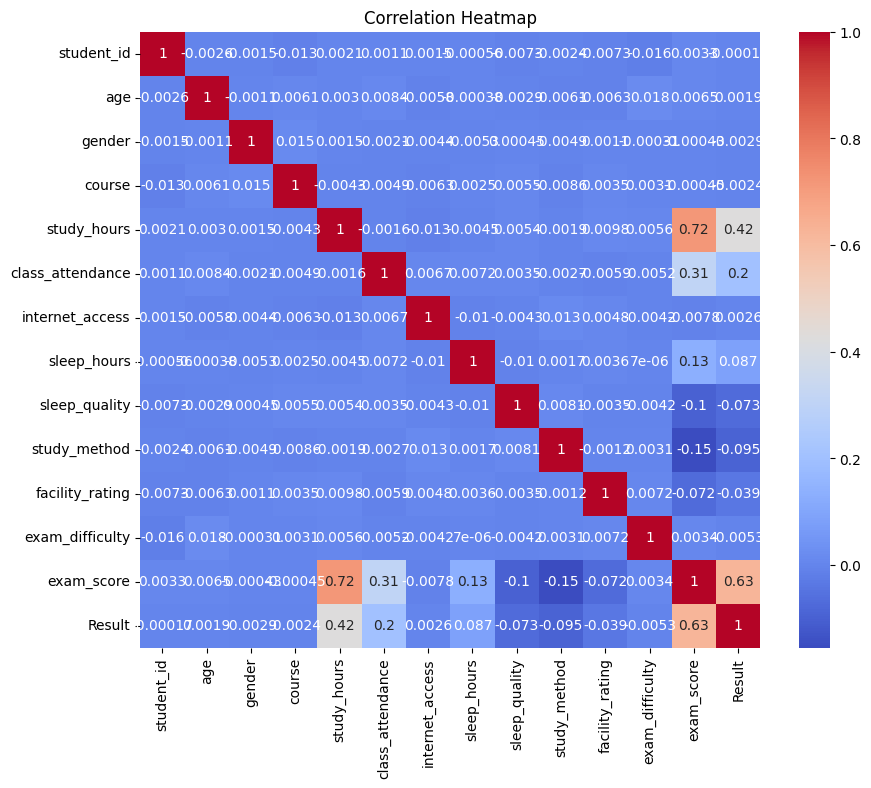

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

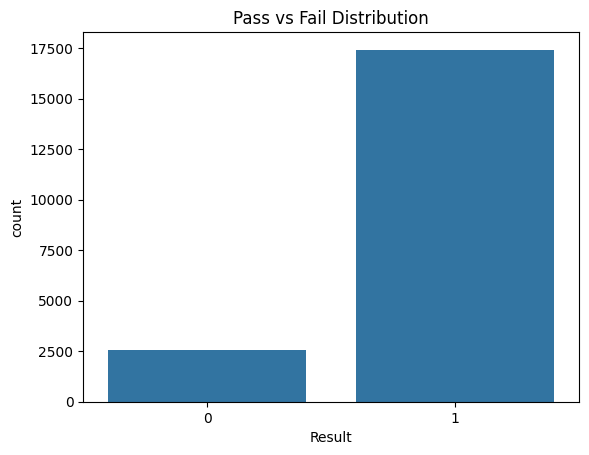

In [ ]:
sns.countplot(x="Result", data=df)

plt.title("Pass vs Fail Distribution")

plt.show()

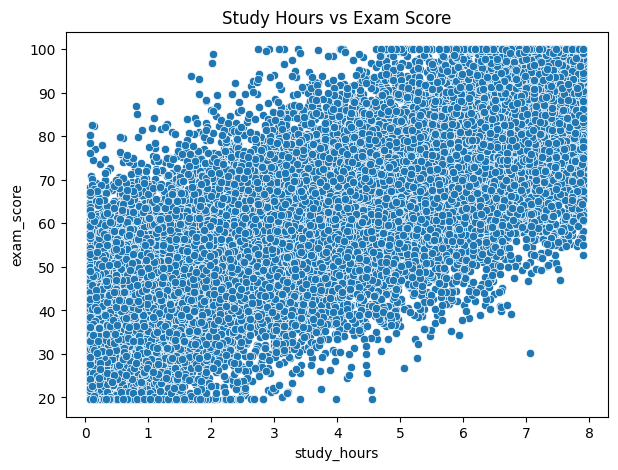

In [ ]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x="study_hours",
    y="exam_score",
    data=df
)

plt.title("Study Hours vs Exam Score")

plt.show()

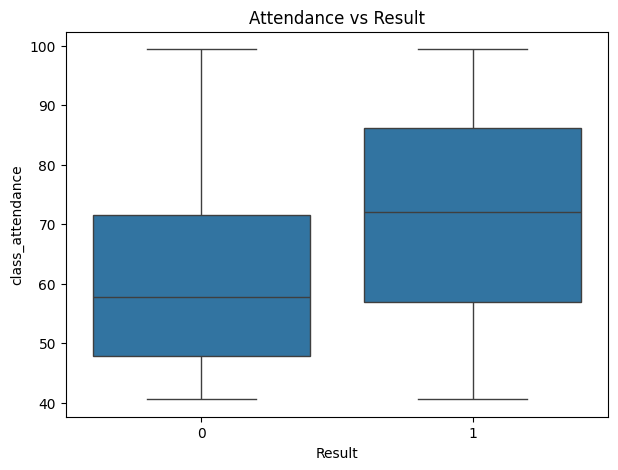

In [ ]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x="Result",
    y="class_attendance",
    data=df
)

plt.title("Attendance vs Result")

plt.show()

# Feature Importance (Decision Tree)

In [ ]:
importance = dt_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

             Feature  Importance
4        study_hours    0.322566
5   class_attendance    0.192026
0         student_id    0.105774
7        sleep_hours    0.100593
3             course    0.048699
9       study_method    0.046646
1                age    0.044187
8      sleep_quality    0.040450
10   facility_rating    0.035596
11   exam_difficulty    0.026985
2             gender    0.023060
6    internet_access    0.013419


# Feature Importance Graph

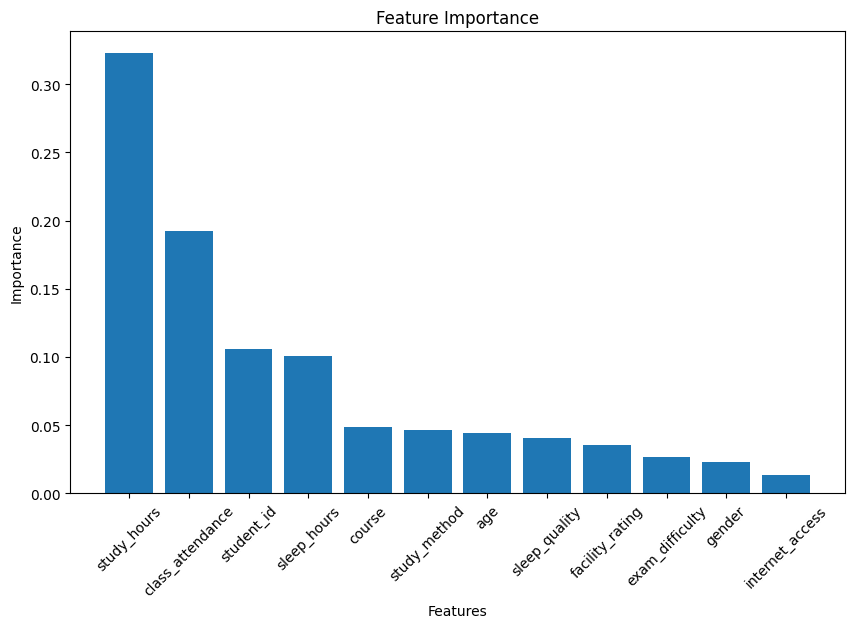

In [ ]:
plt.figure(figsize=(10,6))

plt.bar(feature_importance["Feature"],
         feature_importance["Importance"])

plt.xticks(rotation=45)

plt.title("Feature Importance")

plt.xlabel("Features")

plt.ylabel("Importance")

plt.show()

# Save Models

In [ ]:
import joblib

joblib.dump(dt_model,"DecisionTree_Model.pkl")

joblib.dump(svm_model,"SVM_Model.pkl")

joblib.dump(scaler,"Scaler.pkl")

print("Models Saved Successfully")

Models Saved Successfully


# Predict New Student

In [ ]:
new_student = [[21,21,32,45,37,67,68,57,45,67,89,95]]

new_student = scaler.transform(new_student)

prediction = dt_model.predict(new_student)

if prediction[0] == 1:
    print("PASS")
else:
    print("FAIL")

PASS


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
new_student = [[20,1,2,8,1,7,3,2,4,1,5,2]]

new_student = scaler.transform(new_student)

prediction = dt_model.predict(new_student)

if prediction[0] == 1:
    print("PASS")
else:
    print("FAIL")

FAIL


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
print(df["Result"].value_counts())

Result
1    17425
0     2575
Name: count, dtype: int64


In [ ]:
print("Decision Tree Accuracy:", dt_accuracy)
print("SVM Accuracy:", svm_accuracy)

Decision Tree Accuracy: 0.85525
SVM Accuracy: 0.906


In [ ]:
print(dt_model.predict(new_student))

[0]
